## L1 L2 Feature Selection

Refining features using a two-stage approach:

- **L1**  
  Selects important features → identifies **signal types** (handles sparsity)

- **L2**  
  Applied within each feature group → ranks **features within a signal** (handles collinearity)

### Process

1. Train L1 model on all features  
2. Rank by absolute coefficients  
3. Group features (e.g. liquidity, imbalance, returns)  
4. Fit L2 model per group and rank features  

### Goal

- L1 → *what signals matter*  
- L2 → *which features within those signals are best*

In [254]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [255]:
target = "mid_price_moves"

In [256]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [257]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

final_dataset[target].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

# Important Feature families from L1 
- Volitility
- trade intensity
- total volumes
- shape of the order book
- trade size distrbutions
- imbalances
- trade flow

In [258]:
feature_groups ={
    "volatility": [
        "realized_vol_20_log1p",
        "vol_20_log1p",
        "realized_vol_5_log1p",
        "vol_5_log1p",
    ],
    "trade_intensity":[
        "trade_count_log1p",
        "trade_count_change",
        "buy_count_log1p",
        "sell_count_log1p",
        "total_trade_volume_log1p",
    ],
    "trade_size": [
        "buy_volume_log1p",
        "sell_volume_log1p",
        "avg_trade_size_log1p",
        "max_trade_size_log1p",
        "min_trade_size_log1p",
        "std_trade_size_log1p",
        "max_over_average_log1p",
    ],
    "liquidity": [
        "total_ask_volume_10_log1p",
        "total_bid_volume_10_log1p",
        "total_book_volume_log1p",
        "liquidity_log1p",
        "lob_bids_volume_1_log1p",
        "lob_bids_volume_2_log1p",
        "lob_bids_volume_3_log1p",
        "lob_bids_volume_4_log1p",
        "lob_bids_volume_5_log1p",
        "lob_bids_volume_6_log1p",
        "lob_bids_volume_7_log1p",
        "lob_bids_volume_8_log1p",
        "lob_bids_volume_9_log1p",
        "lob_bids_volume_10_log1p",
    ],

    "volume_pressure": [
        "max_bid_ask_vol_ratio_log1p",
    ],

    "spread": [
        "spread_log1p",
        "rel_spread_log1p",
    ],

    "imbalance": [
        "imbalance_1",
        "imbalance_5",
        "imbalance_10",
        "imbalance_depth_1",
        "imbalance_depth_2",
        "imbalance_depth_3",
        "imbalance_depth_4",
        "imbalance_depth_5",
        "imbalance_depth_6",
        "imbalance_depth_7",
        "imbalance_depth_8",
        "imbalance_depth_9",
        "imbalance_depth_10",
    ],

    "depth_shape": [
        "lob_depth_ratio_2",
        "lob_depth_ratio_3",
        "lob_depth_ratio_4",
        "lob_depth_ratio_5",
        "lob_depth_ratio_6",
        "lob_depth_ratio_7",
        "lob_depth_ratio_8",
        "lob_depth_ratio_9",
        "lob_depth_ratio_10",
    ],

    "trade_flow": [
        "trade_volume_imbalance",
        "trade_volume_change",
        "sell_volume_log1p",
        "buy_volume_log1p"
    ],
}

# training l2 to see which vars in each category are best

In [259]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [260]:
tscv = TimeSeriesSplit(n_splits=10, gap=50)

In [261]:
group = "trade_flow"
X = final_dataset[feature_groups[group]]
y = final_dataset[target]

In [262]:
model = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
    C=1.0,
    max_iter=5000,
)

In [263]:
from joblib import Parallel, delayed
import numpy as np
from sklearn.metrics import roc_auc_score

def run_fold(train_idx, test_idx, X, y, model):

    oof_preds = np.zeros(len(X))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # --- CLIP ---
    lower = X_train.quantile(0.001)
    upper = X_train.quantile(0.999)

    X_train = X_train.clip(lower, upper, axis=1)
    X_test = X_test.clip(lower, upper, axis=1)

    # --- STANDARDISE ---
    mean = X_train.mean()
    std = X_train.std()
    std[std < 1e-12] = 1.0

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    # --- MODEL ---
    model_ = model.__class__(**model.get_params())  # fresh copy
    model_.fit(X_train, y_train)

    preds = model_.predict_proba(X_test)[:, 1]
    oof_preds[test_idx] = preds

    auc = roc_auc_score(y_test, preds)
    coefs = model_.coef_[0]

    return oof_preds, auc, coefs

In [264]:
results = Parallel(n_jobs=4)(
    delayed(run_fold)(train_idx, test_idx, X, y, model)
    for train_idx, test_idx in tscv.split(X)
)

In [265]:
all_oof_preds = []
fold_aucs = []
coefs = []

for oof, auc, coef in results:
    all_oof_preds.append(oof)
    fold_aucs.append(auc)
    coefs.append(coef)

[0.6619994993847149, 0.5243709754730522, 0.5117025830623562, 0.4974449424357007, 0.5132974159603012, 0.5431266202483138, 0.5108793627109421, 0.5797192930128457, 0.6121594936197781, 0.6742947640228323]


C:\Users\jayod\AppData\Local\Temp\ipykernel_12348\2869559075.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'AUC per Fold')

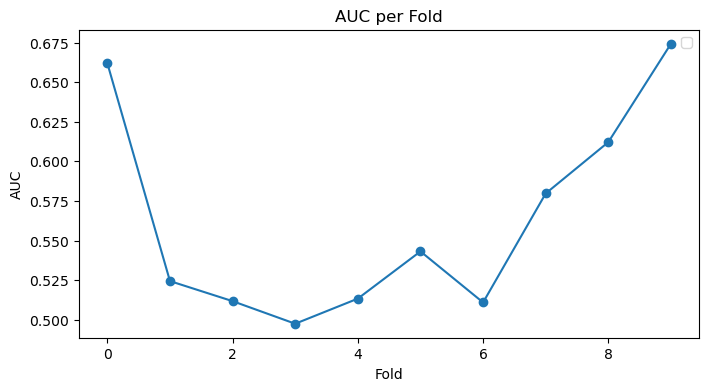

In [266]:
print(fold_aucs)
plt.figure(figsize=(8,4))

plt.plot(fold_aucs, marker="o")

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.legend()
plt.title("AUC per Fold")

In [267]:
final_preds = np.sum(all_oof_preds, axis=0)
y_true = y.values

Text(0.5, 1.0, 'Rolling Calibration (window=500)')

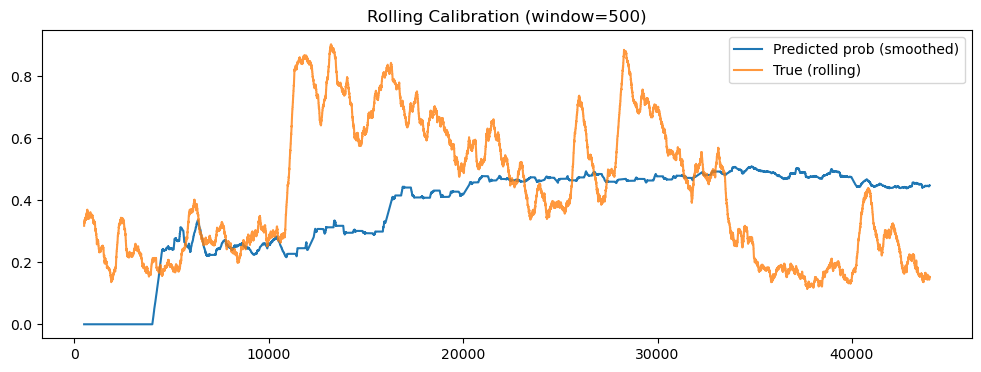

In [268]:
import matplotlib.pyplot as plt

window = 500

pred_smooth = pd.Series(final_preds).rolling(window).mean()
target_smooth = pd.Series(y_true).rolling(window).mean()

plt.figure(figsize=(12,4))
plt.plot(pred_smooth, label="Predicted prob (smoothed)")
plt.plot(target_smooth, label="True (rolling)", alpha=0.8)
plt.legend()
plt.title(f"Rolling Calibration (window={window})")

Text(0.5, 1.0, 'Prediction distribution')

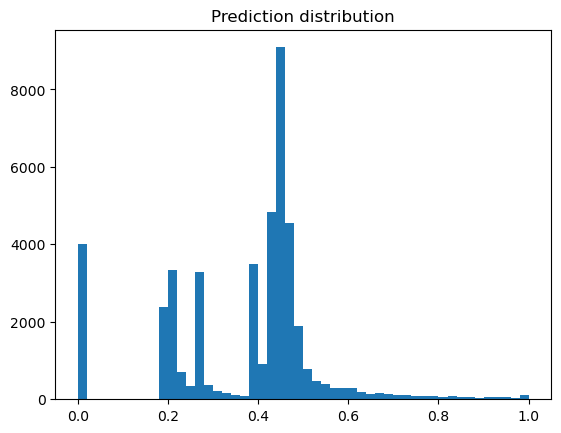

In [269]:
plt.hist(final_preds, bins=50)
plt.title("Prediction distribution")

In [270]:
import pandas as pd

avg_coefs = pd.Series(np.mean(np.abs(coefs), axis=0), index=feature_groups[group])
avg_coefs = avg_coefs.sort_values(key=abs, ascending=False)
pd.set_option("display.max_rows", None)
print(avg_coefs)

sell_volume_log1p         0.397013
buy_volume_log1p          0.321524
trade_volume_imbalance    0.025055
trade_volume_change       0.020249
dtype: float64


In [271]:
sorted_tables = []

for i in range(len(coefs)):
    s = pd.Series(coefs[i], index=feature_groups[group])
    s = s.sort_values(key=abs, ascending=False)

    df_fold = pd.DataFrame({
        f"Fold_{i}_feature": s.index,
        f"Fold_{i}_coef": s.values
    })

    sorted_tables.append(df_fold.reset_index(drop=True))

In [272]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


coef_table = pd.concat(sorted_tables, axis=1)

print(coef_table)

           Fold_0_feature  Fold_0_coef          Fold_1_feature  Fold_1_coef          Fold_2_feature  Fold_2_coef          Fold_3_feature  Fold_3_coef          Fold_4_feature  Fold_4_coef          Fold_5_feature  Fold_5_coef          Fold_6_feature  Fold_6_coef          Fold_7_feature  Fold_7_coef          Fold_8_feature  Fold_8_coef          Fold_9_feature  Fold_9_coef
0       sell_volume_log1p     1.152830       sell_volume_log1p     0.602216       sell_volume_log1p     0.461670       sell_volume_log1p     0.337241       sell_volume_log1p     0.284139        buy_volume_log1p     0.256688        buy_volume_log1p     0.244407        buy_volume_log1p     0.225715       sell_volume_log1p     0.224592       sell_volume_log1p     0.214744
1        buy_volume_log1p     0.583896        buy_volume_log1p     0.507465        buy_volume_log1p     0.438156        buy_volume_log1p     0.310630        buy_volume_log1p     0.277074       sell_volume_log1p     0.240917       sell_volume_log1p     0.23

In [273]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["feature", "avg_coef"]

for feature, coef in avg_coefs.round(4).items():
    table.add_row([feature, coef])

with open(f"C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l2_feature_select\\avg_{group}.txt", "w") as f:
    f.write(str(table))

In [ ]:
features = [
    # Vol
    "realized_vol_20_log1p",
    "realized_vol_5_log1p",

    # trade intensity
    "trade_count_log1p",
    "trade_count_change",

    # trade size
    "std_trade_size_log1p",
    "max_trade_size_log1p",
    "avg_trade_size_log1p",

    # liquidity
    "total_bid_volume_10_log1p",
    "total_book_volume_log1p",

    # volume_pressure
    "max_bid_ask_vol_ratio_log1p",

    # spread
    "rel_spread_log1p",

    # imbalance
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_3",

    # depth shape
    "lob_depth_ratio_4",
    "lob_depth_ratio_2",

    # trade_flow
    "sell_volume_log1p",
]

# features chosen
#### Vol
- realized_vol_20_log1p 
- realized_vol_5_log1p
#### trade intensity
- trade_count_log1p
- trade_count_change
#### trade size
- std_trade_size_log1p
- max_trade_size_log1p
- avg_trade_size_log1p
#### liquidity
- total_bid_volume_10_log1p
- total_book_volume_log1p
#### volume_pressure
- max_bid_ask_vol_ratio_log1p
#### spread
- rel_spread_log1p
#### imbalance
- imbalance_5   
- imbalance_10  
- imbalance_depth_3
#### depth shape
- lob_depth_ratio_4
- lob_depth_ratio_2
#### trade_flow
- sell_volume_log1p


